# Importing Libraries

In [13]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Extracting Dataset

In [14]:
zip_path = "/content/archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


# Defining Transforms

In [15]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

# Loading Dataset

In [16]:
train_dataset = datasets.ImageFolder(
    root="/content/mnist_png/training",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="/content/mnist_png/testing",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Training Images: 60000
Testing Images: 10000


# Adding Noise Function

In [17]:
def add_noise(images, noise_factor=0.5):

    noisy = images + noise_factor * torch.randn_like(images)

    noisy = torch.clamp(noisy, 0., 1.)

    return noisy

# Visualizing Noisy Images

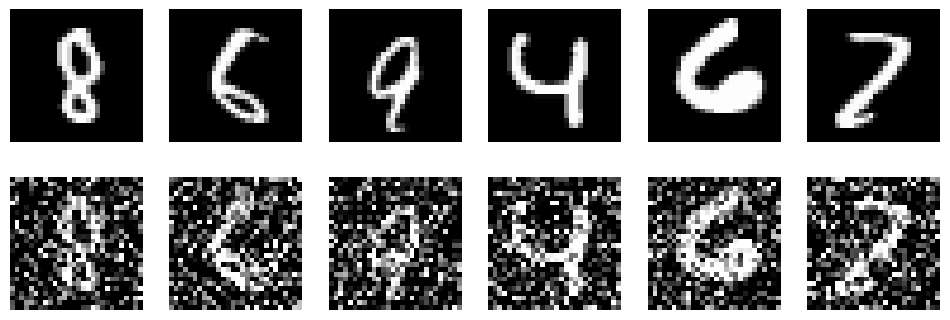

In [18]:
images, _ = next(iter(train_loader))

noisy_images = add_noise(images)

fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):
    axes[0,i].imshow(images[i].squeeze(), cmap='gray')
    axes[0,i].axis('off')

    axes[1,i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[1,i].axis('off')

plt.show()

# Building Convolutional Autoencoder

In [19]:
class DenoisingAutoencoder(nn.Module):

    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 7)
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(64, 32, 7),
            nn.ReLU(),

            nn.ConvTranspose2d(
                32,
                16,
                3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                16,
                1,
                3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

# Initializing Model

In [20]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)


# Model Training

In [21]:
num_epochs = 20

train_losses = []

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)

        noisy_images = add_noise(images)

        optimizer.zero_grad()

        outputs = model(noisy_images)

        loss = criterion(outputs, images)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.6f}"
    )

Epoch [1/20] Loss: 0.059516
Epoch [2/20] Loss: 0.021344
Epoch [3/20] Loss: 0.016452
Epoch [4/20] Loss: 0.014556
Epoch [5/20] Loss: 0.013490
Epoch [6/20] Loss: 0.012829
Epoch [7/20] Loss: 0.012377
Epoch [8/20] Loss: 0.012069
Epoch [9/20] Loss: 0.011799
Epoch [10/20] Loss: 0.011626
Epoch [11/20] Loss: 0.011447
Epoch [12/20] Loss: 0.011311
Epoch [13/20] Loss: 0.011207
Epoch [14/20] Loss: 0.011093
Epoch [15/20] Loss: 0.011023
Epoch [16/20] Loss: 0.010971
Epoch [17/20] Loss: 0.010904
Epoch [18/20] Loss: 0.010843
Epoch [19/20] Loss: 0.010800
Epoch [20/20] Loss: 0.010745


# Plotting Training Loss

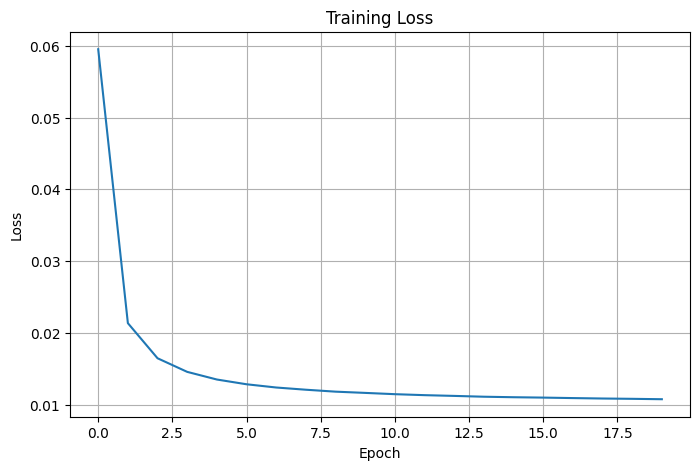

In [22]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

# Test Reconstruction

In [23]:
model.eval()

with torch.no_grad():

    images, _ = next(iter(test_loader))

    images = images.to(device)

    noisy_images = add_noise(images)

    reconstructed = model(noisy_images)

images = images.cpu()
noisy_images = noisy_images.cpu()
reconstructed = reconstructed.cpu()

# Results

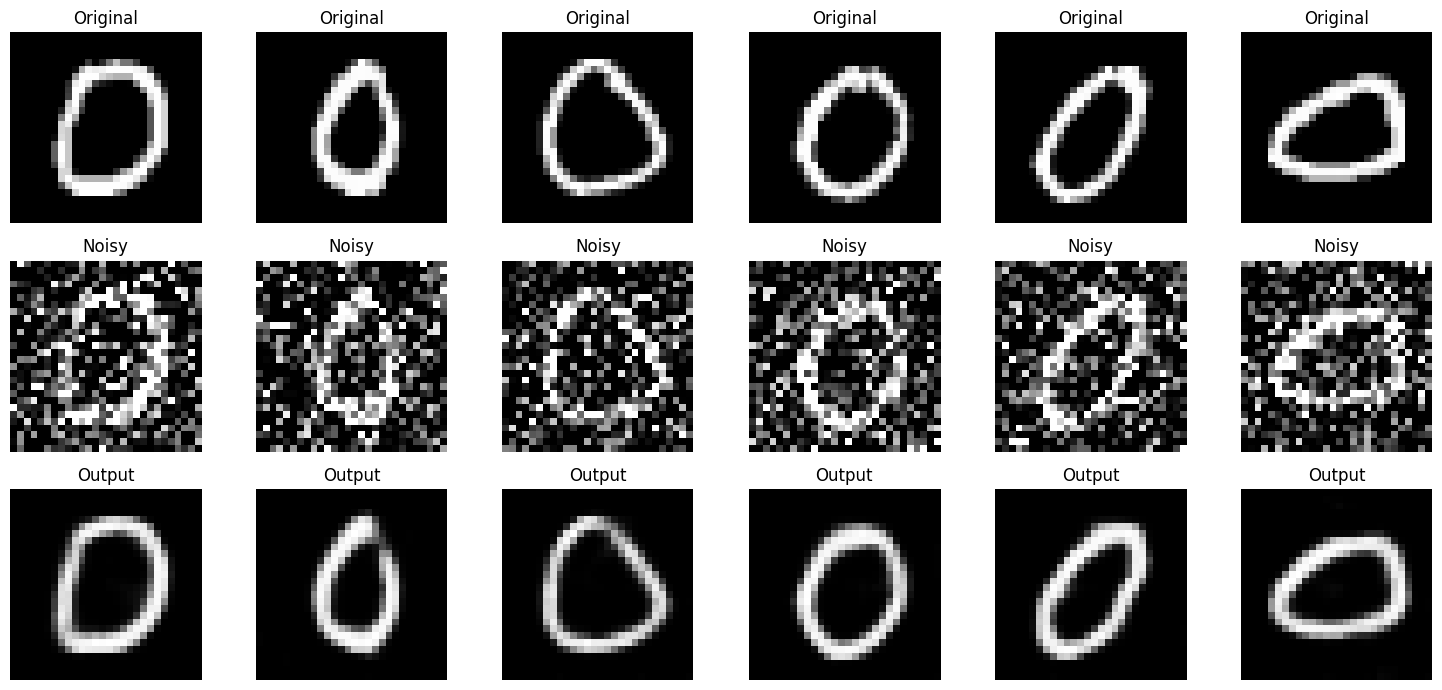

In [24]:
n = 6

plt.figure(figsize=(15,7))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("Output")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Observations

- The training loss decreased significantly from approximately 0.059 to 0.011, indicating that the autoencoder successfully learned how to reconstruct clean images from noisy inputs.

- Most of the loss reduction occurred during the first 2–3 epochs, showing that the model quickly learned the major patterns of handwritten digits.

- The noisy images contain heavy Gaussian noise, making the digits difficult to recognize. However, the reconstructed outputs clearly preserve the digit shapes while removing most of the random noise.

- The encoder successfully captured the essential structure of the digits and ignored irrelevant noisy pixels, demonstrating effective feature learning.

- The output images are smoother and slightly blurrier than the originals. This is expected because autoencoders focus on reconstructing the overall digit structure rather than every pixel perfectly.

- The model performed well on unseen test images, indicating that it learned generalized digit representations rather than memorizing the training data.

# Conclusion

The Convolutional Denoising Autoencoder successfully learned to remove Gaussian noise from MNIST handwritten digit images. The steady reduction in training loss and the visual quality of the reconstructed images demonstrate that the model effectively extracts meaningful features while suppressing noise. Although the reconstructed digits appear slightly blurred, they remain highly recognizable, confirming the effectiveness of autoencoders for image denoising and restoration tasks.
